In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
import torch 
from clean_utils import *

PATCHES_FOLDER = "/rds/rds-clecat/generative_modelling/CIB_run1_first10"  


OUT_ROOT       = "/rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2"
OUT_PATCHES_NORM = os.path.join(OUT_ROOT, "patches_norm")  
OUT_PATCHES_RAW  = os.path.join(OUT_ROOT, "patches_raw")   
OUT_SYNTH_RAW    = os.path.join(OUT_ROOT, "synth_raw")      
OUT_SYNTH_RAW_DS = os.path.join(OUT_ROOT, "synth_raw_down2")# synth downsampled 1/2
OUT_SYNTH_NORM = os.path.join(OUT_ROOT, "synth_norm")   


for d in [OUT_PATCHES_NORM, OUT_PATCHES_RAW, OUT_SYNTH_NORM, OUT_SYNTH_RAW]:
    os.makedirs(d, exist_ok=True)

print("NEW OUT_ROOT =", OUT_ROOT)


os.makedirs(OUT_PATCHES_RAW, exist_ok=True)
os.makedirs(OUT_SYNTH_RAW_DS, exist_ok=True)

print("OUT_PATCHES_RAW:", OUT_PATCHES_RAW)
print("OUT_SYNTH_RAW:", OUT_SYNTH_RAW)
print("OUT_SYNTH_RAW_DS:", OUT_SYNTH_RAW_DS)

NEW OUT_ROOT = /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2
OUT_PATCHES_RAW: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/patches_raw
OUT_SYNTH_RAW: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/synth_raw
OUT_SYNTH_RAW_DS: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/synth_raw_down2


Load patches

In [2]:
patches_raw, patch_paths = safe_load_patches(PATCHES_FOLDER, max_load=None)
print("Loaded patches_raw shape:", patches_raw.shape)
print("First file loaded:", patch_paths[0])

Loaded patches_raw shape: (10, 512, 512)
First file loaded: /rds/rds-clecat/generative_modelling/CIB_run1_first10/patch_000000.npy


Standardize patches

In [3]:
patch_means = patches_raw.mean(axis=(1,2))
patch_stds  = patches_raw.std(axis=(1,2))
patch_stds  = np.maximum(patch_stds, 1e-12)
patches_z = (patches_raw - patch_means[:,None,None]) / patch_stds[:,None,None]
print("patches_z shape:", patches_z.shape, " mean≈", patches_z.mean(), " std≈", patches_z.std())

patches_z shape: (10, 512, 512)  mean≈ -1.8836e-08  std≈ 1.0


Normalize patches

In [4]:
# fit A,B sur patches_z (identique à ton flow)
A, B = find_parameters(patches_z, verbose=True, max_iter=5000)
print("Fitted A,B:", A, B)

patches_norm, mean_log, std_log = normalize_array(patches_z, A, B, eps=0)
print("patches_norm shape:", patches_norm.shape, " mean≈", patches_norm.mean(), " std≈", patches_norm.std())

# sauvegarde des paramètres de normalisation
np.savez(os.path.join(OUT_ROOT, "norm_params.npz"),
         A=A, B=B, mean_log=mean_log, std_log=std_log,
         patch_means=patch_means, patch_stds=patch_stds)

# sauvegarde patches_norm dans OUT_PATCHES_NORM 
for i, arr in enumerate(patches_norm):
    outp = os.path.join(OUT_PATCHES_NORM, f"target_norm_{i:04d}.npy")
    np.save(outp, arr.astype(np.float32))
print("Saved normalized target patches to:", OUT_PATCHES_NORM)

Optimization terminated successfully.
         Current function value: 0.029006
         Iterations: 49
         Function evaluations: 99
Fitted A,B: 0.7448273687468272 6.367743501693722
patches_norm shape: (10, 512, 512)  mean≈ -1.3281910293816424e-14  std≈ 0.9999999999999998
Saved normalized target patches to: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/patches_norm


Synthesis

In [5]:
import sys
sys.path.append('/rds/rds-clecat/generative_modelling/STL_4')
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass
from mean_field_handmade_123 import optimize_scattering_LBFGS_mean

# target DataClass > du premier patch normalisé 
first_patch = patches_norm[0].astype(np.float64)    
target_DC = DataClass(first_patch, pbc=False)
st_op_running = target_DC.get_ST_op(compute_PS=True)
st_op_target = target_DC.get_ST_op(compute_PS=True)

torch.set_default_dtype(torch.float64)

u_opt, loss_history = optimize_scattering_LBFGS_mean(
    target=target_DC,
    st_op_target=st_op_target,
    st_op_running=st_op_running,
    pbc_running=True,
    compute_cross_matrix=None,
    max_iter=900,
    nbatch=10,
    lr=1.0,
    history_size=100,
    print_iter=50,
    verbose=True,
    seed=100,
    patches=patches_norm,
)

u_np = u_opt.detach().cpu().numpy()
if u_np.ndim == 4 and u_np.shape[1] == 1:
    u_np = u_np[:,0]
    
# sauvegarde des synthèses normalisées et raw
for b in range(u_np.shape[0]):
    u_norm = u_np[b]
    np.save(os.path.join(OUT_SYNTH_NORM, f"synth_norm_{b:03d}.npy"), u_norm.astype(np.float32))
    # inverse log-normal + inverse standardisation par patch
    u_z = denormalize_array(u_norm, mean_log, std_log, A, B)
    idx = b if b < len(patch_means) else 0
    u_raw = u_z * patch_stds[idx] + patch_means[idx]
    np.save(os.path.join(OUT_SYNTH_RAW, f"synth_raw_{b:03d}.npy"), u_raw.astype(np.float32))

print("Saved synth_norm ->", OUT_SYNTH_NORM)
print("Saved synth_raw  ->", OUT_SYNTH_RAW)

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (10, 1, 512, 512)
Synthesis on 5914 ST coefficients
[LBFGS] inner iter 50, loss = 1.294104e-02
[LBFGS] inner iter 100, loss = 7.162895e-05
[LBFGS] inner iter 150, loss = 3.605965e-05
[LBFGS] inner iter 200, loss = 2.603917e-05
[LBFGS] inner iter 250, loss = 1.484492e-05
[LBFGS] inner iter 300, loss = 1.064439e-05
[LBFGS] inner iter 350, loss = 7.610968e-06
[LBFGS] inner iter 400, loss = 6.124463e-06
[LBFGS] inner iter 450, loss = 4.984831e-06
[LBFGS] inner iter 500, loss = 3.994924e-06
[LBFGS] inner iter 550, loss = 3.170225e-06
[LBFGS] inner iter 600, loss = 2.608107e-06
[LBFGS] inner iter 650, loss = 2.259301e-06
[LBFGS] inner iter 700, loss = 2.002515e-06
[LBFGS] inner iter 750, loss = 1.782825e-06
[LBFGS] inner iter 800, loss = 1.604705e-06
[LBFGS] inner iter 850, loss = 1.393781e-06
[LBFGS] inner iter 900, loss = 1.279112e-06
937 iterations of synthesis done with nbatch=10 and 5914 ST coefficients
Executio

# Lognormal space

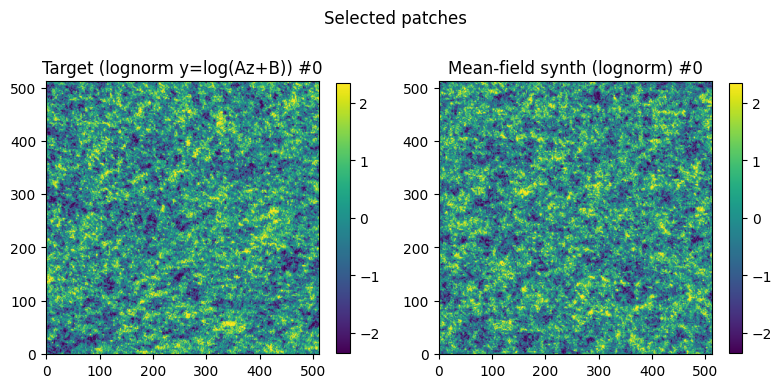

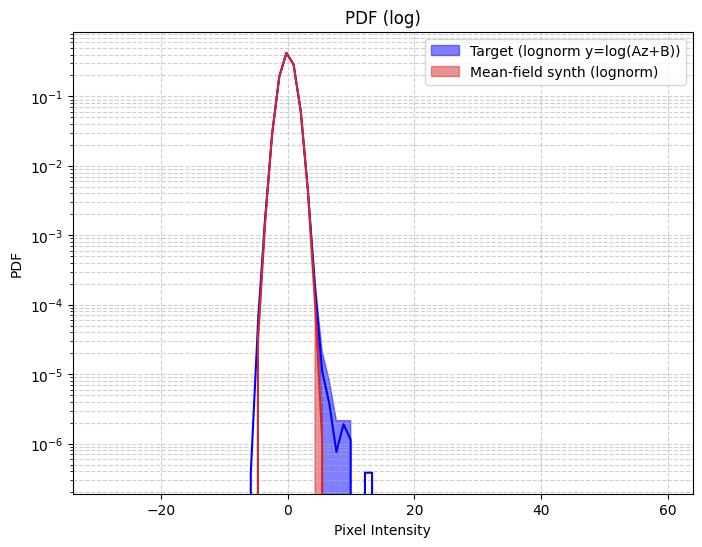

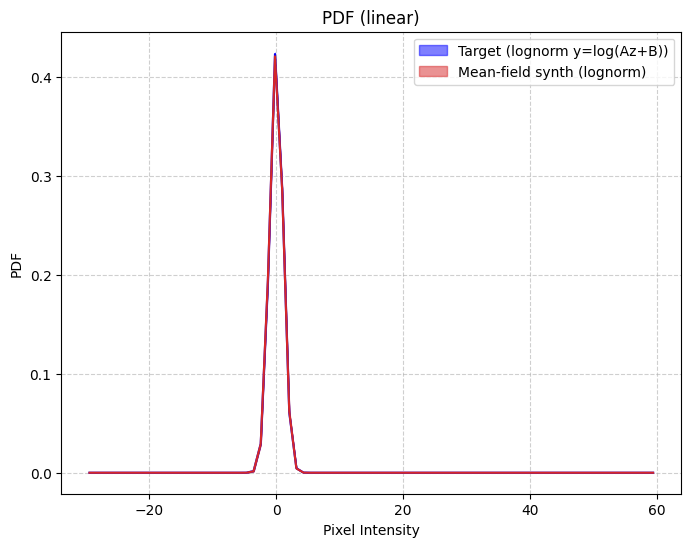

[DEBUG PS] Target (lognorm y=log(Az+B)) min= 7344.917197464921 max= 63954187.712535836 any>0? True any nan? False shape= (10, 252)
[DEBUG PS] Mean-field synth (lognorm) min= 1815.627341502781 max= 66095070.50591172 any>0? True any nan? False shape= (10, 252)


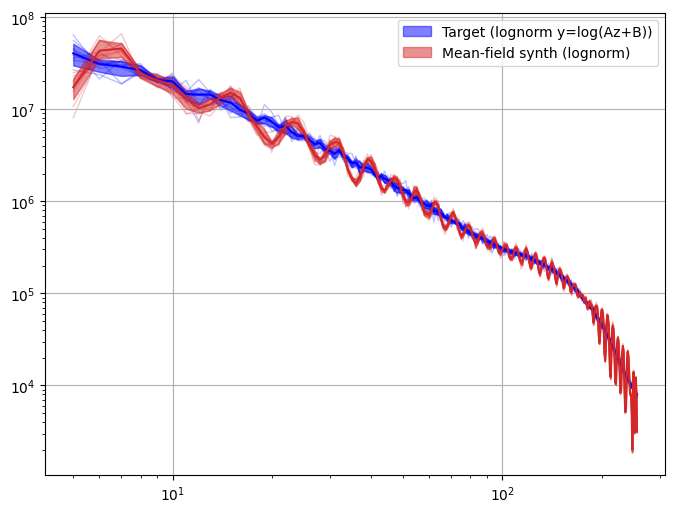

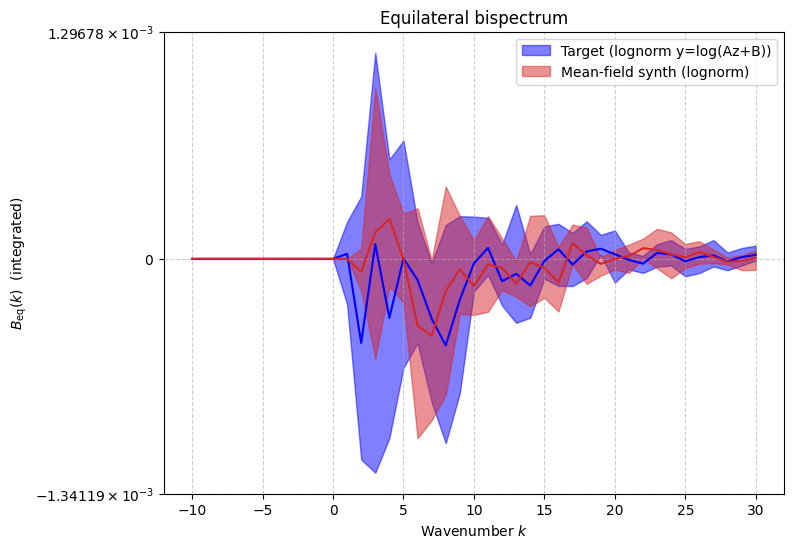

/rds/rds-clecat/generative_modelling/clean_utils.py:488: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.78)


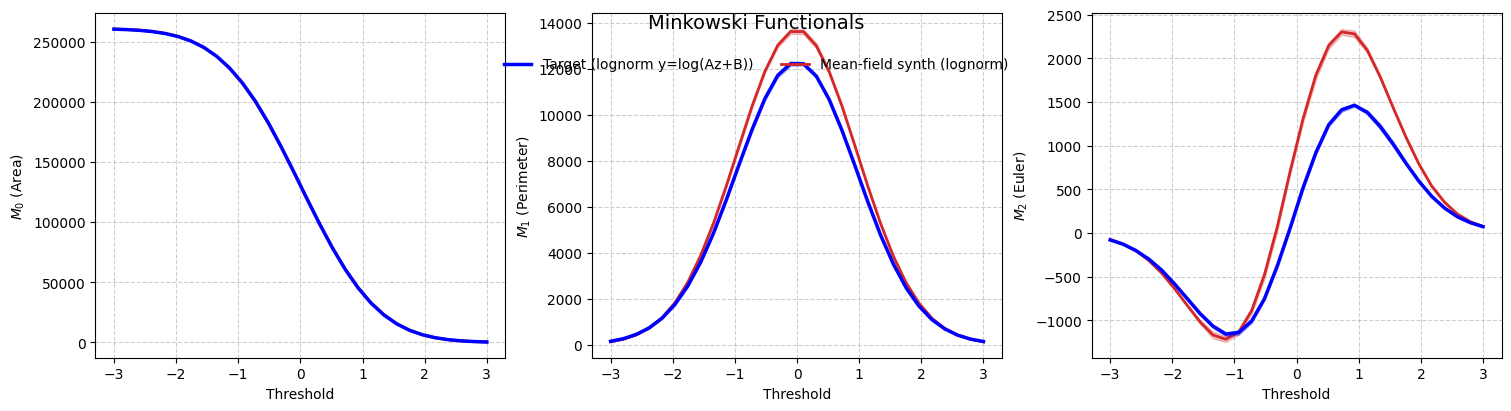

In [6]:
fa_lognorm = flexible_analysis(
    folders=[OUT_PATCHES_NORM, OUT_SYNTH_NORM],   
    labels=["Target (lognorm y=log(Az+B))", "Mean-field synth (lognorm)"],
    colors=["blue", "tab:red"],

    ps_kmin=5,
    ps_kmax=300,

    ps_plot_individual_n=10,          
    ps_individual_mode="first",     
    ps_individual_seed=0,             

    imshow_indices=[0, 0],    
    pdf_bins=80,
    pdf_range=(-30, 60),
    mf_min_threshold=-3,
    mf_max_threshold=3,
    gaussian=False,
    show=True,

    bispectrum=True,
    bisp_kmin=-10,
    bisp_kmax=30,
    bisp_width=2.0,
    bisp_yscale="symlog",
)

# Denormalized

In [7]:
#patches_norm -> patches_raw 
if len(sorted(glob.glob(os.path.join(OUT_PATCHES_RAW, "*.npy")))) > 0:
    print("OUT_PATCHES_RAW already contains files; skipping reconstruction") #si on a déjà reconstruit les patches
else:
    # charge paramètres
    npz_path = os.path.join(OUT_ROOT, "norm_params.npz")
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"norm_params.npz not found at {npz_path} — cannot denormalize.")
    params = np.load(npz_path)
    A = params["A"]; B = params["B"]
    mean_log = params["mean_log"]; std_log = params["std_log"]
    patch_means = params["patch_means"]; patch_stds = params["patch_stds"]

    # liste fichiers normalisés
    norm_files = sorted(glob.glob(os.path.join(OUT_PATCHES_NORM, "*.npy")))
    if len(norm_files) == 0:
        raise RuntimeError(f"No normalized files found in {OUT_PATCHES_NORM}")
        
    for i, fn in enumerate(norm_files):
        arr_norm = np.load(fn).astype(np.float64)    # forme (H,W)
        # inverse log-normal et inverse standardisation par patch
        arr_z = denormalize_array(arr_norm, mean_log, std_log, A, B)    # arr_z same shape
        idx = i if i < len(patch_means) else 0
        arr_raw = arr_z * patch_stds[idx] + patch_means[idx]
        outp = os.path.join(OUT_PATCHES_RAW, f"target_raw_{i:04d}.npy")
        np.save(outp, arr_raw.astype(np.float32))
    print(f"Saved {len(norm_files)} denormalized target patches to {OUT_PATCHES_RAW}")


Saved 10 denormalized target patches to /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/patches_raw


N target raw files: 10
N synth raw files : 10


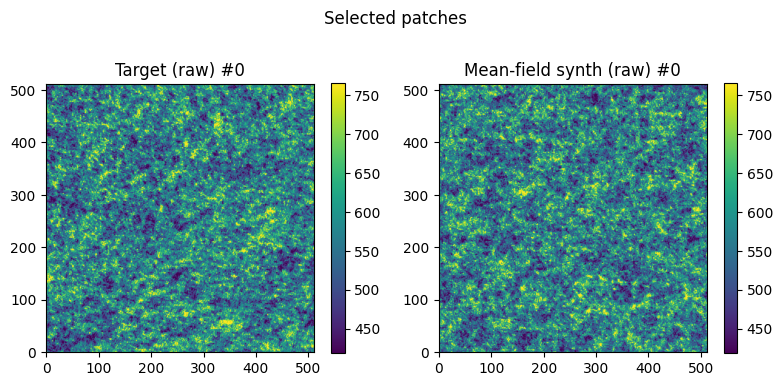

/rds/rds-clecat/generative_modelling/gm_env/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x600 with 1 Axes>

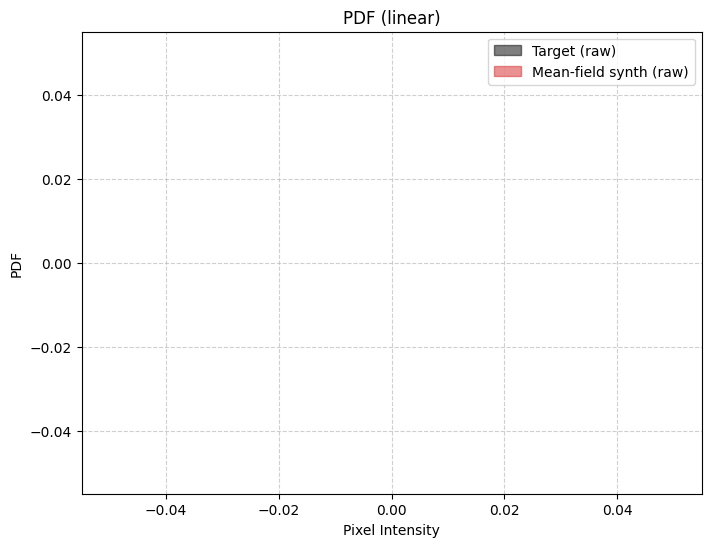

[DEBUG PS] Target (raw) min= 93339886.0378933 max= 360562233715.8104 any>0? True any nan? False shape= (10, 222)
[DEBUG PS] Mean-field synth (raw) min= 56617794.48128145 max= 365990057381.07947 any>0? True any nan? False shape= (10, 222)


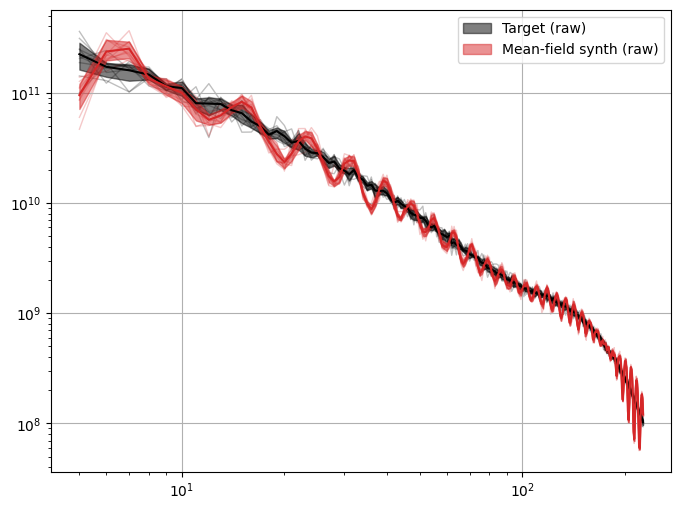

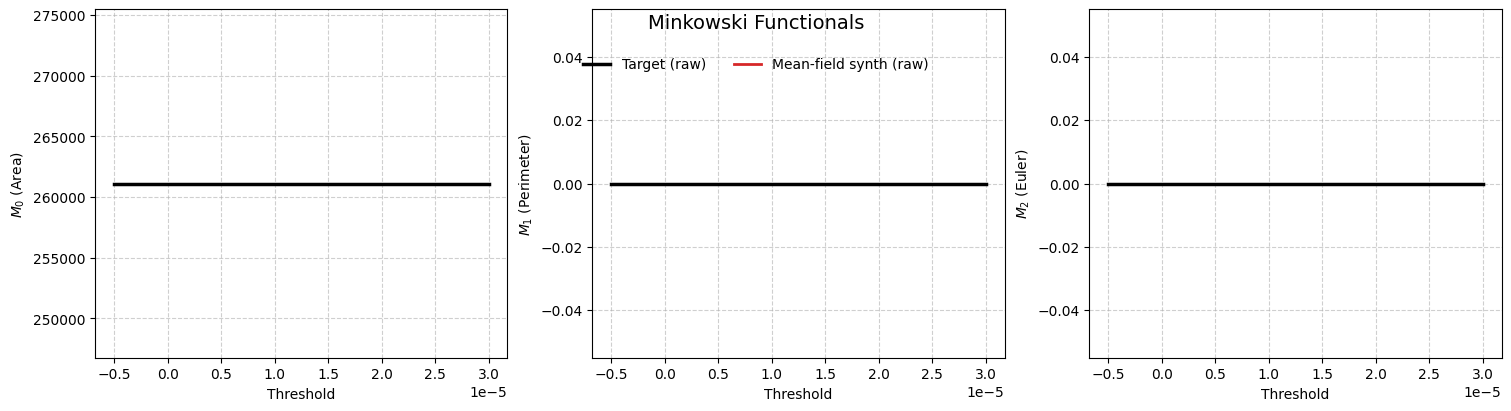

In [8]:
# Cell C — flexible_analysis sur patches raw et synth raw
from clean_utils import flexible_analysis
import glob, os

tar_files = sorted(glob.glob(os.path.join(OUT_PATCHES_RAW, "*.npy")))
synth_files = sorted(glob.glob(os.path.join(OUT_SYNTH_RAW, "*.npy")))
print("N target raw files:", len(tar_files))
print("N synth raw files :", len(synth_files))

fa_raw = flexible_analysis(
    folders=[OUT_PATCHES_RAW, OUT_SYNTH_RAW], #pour les patches raw, on a normalisé puis dénormalisé
    labels=["Target (raw)", "Mean-field synth (raw)"],
    colors=["black", "tab:red"],
    ps_kmin=5, ps_kmax=226,
    ps_plot_individual_n=10,
    ps_individual_mode="top_impact",  # ou "random"
    ps_individual_seed=0,
    imshow_indices=[0, 0],
    pdf_bins=80,
    pdf_range=(-1e-5, 6.5e-4),
    mf_min_threshold=-0.5e-5,
    mf_max_threshold=3e-5,
    gaussian=False,
    show=True,
)

In [9]:
t = np.load(tar_files[7])
s = np.load(synth_files[0])
print("means:", t.mean(), s.mean())
print("stds :", t.std(),  s.std())

means: 576.7572 572.59894
stds : 74.951485 74.162636


# Downsampling

In [10]:
synth_raw_files = sorted(glob.glob(os.path.join(OUT_SYNTH_RAW, "*.npy")))
print("Found synth_raw files:", len(synth_raw_files))

for fn in synth_raw_files:
    arr = np.load(fn)

    if arr.ndim != 2:
        raise ValueError(f"Expected 2D arrays, got shape {arr.shape} for {fn}")

    arr_filt = uniform_filter(arr, size=2, mode="wrap")*4 #filter
    arr_ds2  = arr_filt[::2, ::2]
    base = os.path.basename(fn).replace(".npy", "")
    outp = os.path.join(OUT_SYNTH_RAW_DS, f"{base}_ds2.npy")
    np.save(outp, arr_ds2.astype(np.float32))
print("Saved downsampled synth to:", OUT_SYNTH_RAW_DS)

Found synth_raw files: 10
Saved downsampled synth to: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/synth_raw_down2


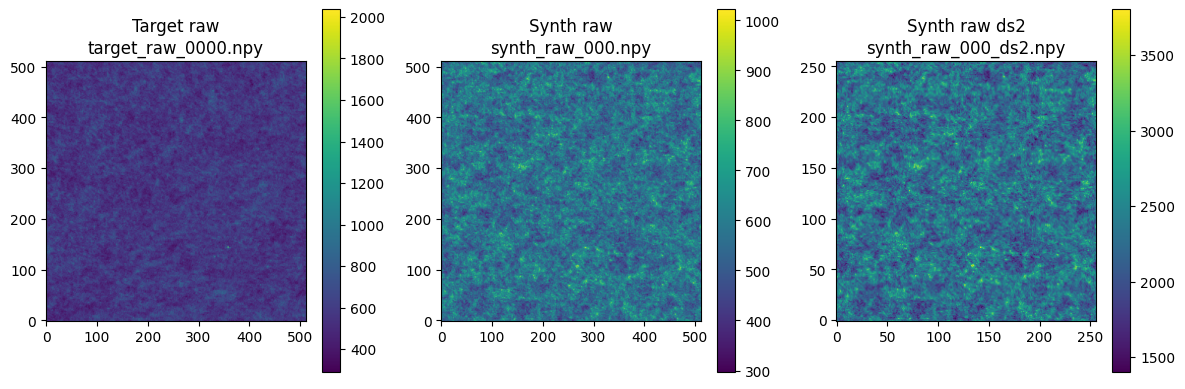

In [11]:
#Sanity check
def load_first(folder, pattern="*.npy"):
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if len(files) == 0:
        return None, None
    return np.load(files[0]), files[0]

t_raw, t_path = load_first(OUT_PATCHES_RAW)
s_raw, s_path = load_first(OUT_SYNTH_RAW)
s_ds, s_ds_path = load_first(OUT_SYNTH_RAW_DS, pattern="*ds2.npy")

ncols = 3
plt.figure(figsize=(4*ncols,4))
if t_raw is not None:
    plt.subplot(1,ncols,1); plt.imshow(t_raw, origin='lower'); plt.colorbar(); plt.title(f"Target raw\n{os.path.basename(t_path)}")
else:
    plt.subplot(1,ncols,1); plt.text(0.5,0.5,"No target raw",ha='center'); plt.axis('off')

if s_raw is not None:
    plt.subplot(1,ncols,2); plt.imshow(s_raw, origin='lower'); plt.colorbar(); plt.title(f"Synth raw\n{os.path.basename(s_path)}")
else:
    plt.subplot(1,ncols,2); plt.text(0.5,0.5,"No synth raw",ha='center'); plt.axis('off')

if s_ds is not None:
    plt.subplot(1,ncols,3); plt.imshow(s_ds, origin='lower'); plt.colorbar(); plt.title(f"Synth raw ds2\n{os.path.basename(s_ds_path)}")
else:
    plt.subplot(1,ncols,3); plt.text(0.5,0.5,"No synth ds2",ha='center'); plt.axis('off')

plt.tight_layout(); plt.show()


/tmp/ipykernel_1335266/3258306925.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # laisse de la place à droite


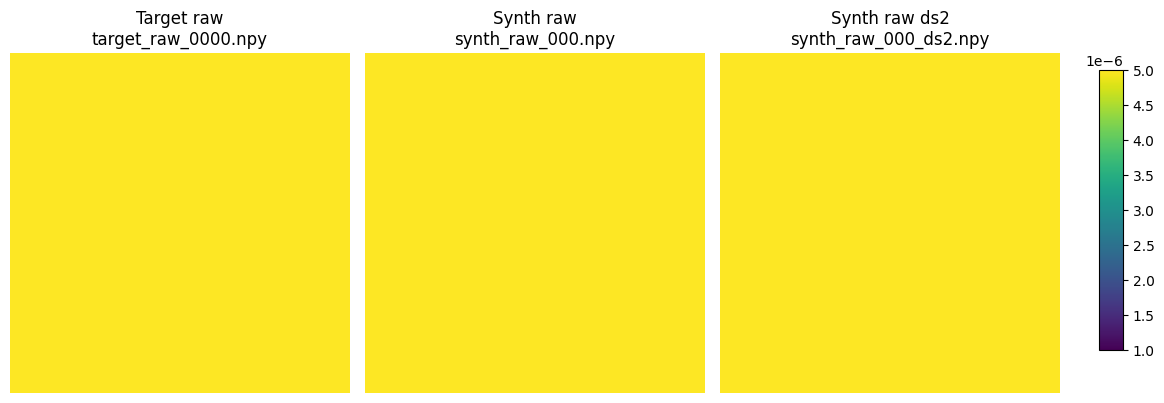

In [12]:
VMIN, VMAX = 1e-6, 5e-6
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

ims = []
for ax, arr, title in [
    (axs[0], t_raw, f"Target raw\n{os.path.basename(t_path)}"),
    (axs[1], s_raw, f"Synth raw\n{os.path.basename(s_path)}"),
    (axs[2], s_ds/4,  f"Synth raw ds2\n{os.path.basename(s_ds_path)}"),
]:
    if arr is None:
        ax.text(0.5, 0.5, "None", ha="center", va="center")
        ax.axis("off")
        continue
    im = ax.imshow(arr, origin="lower", vmin=VMIN, vmax=VMAX)
    ax.set_title(title)
    ax.axis("off")
    ims.append(im)

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
# [left, bottom, width, height] en fraction de figure

fig.colorbar(ims[0], cax=cax)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # laisse de la place à droite
plt.show()


In [13]:
OUT_PATCHES_RAW_DS = os.path.join(OUT_ROOT, "patches_raw_down2")
os.makedirs(OUT_PATCHES_RAW_DS, exist_ok=True)

target_raw_files = sorted(glob.glob(os.path.join(OUT_PATCHES_RAW, "*.npy")))
print("Found target_raw files:", len(target_raw_files))

for fn in target_raw_files:
    arr = np.load(fn)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D arrays, got shape {arr.shape} for {fn}")
    arr_filt = uniform_filter(arr, size=2, mode="wrap")*4
    arr_ds2  = arr_filt[::2, ::2]
    base = os.path.basename(fn).replace(".npy", "")
    outp = os.path.join(OUT_PATCHES_RAW_DS, f"{base}_ds2.npy")
    np.save(outp, arr_ds2.astype(np.float32))

print("Saved downsampled target to:", OUT_PATCHES_RAW_DS)


Found target_raw files: 10
Saved downsampled target to: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/patches_raw_down2


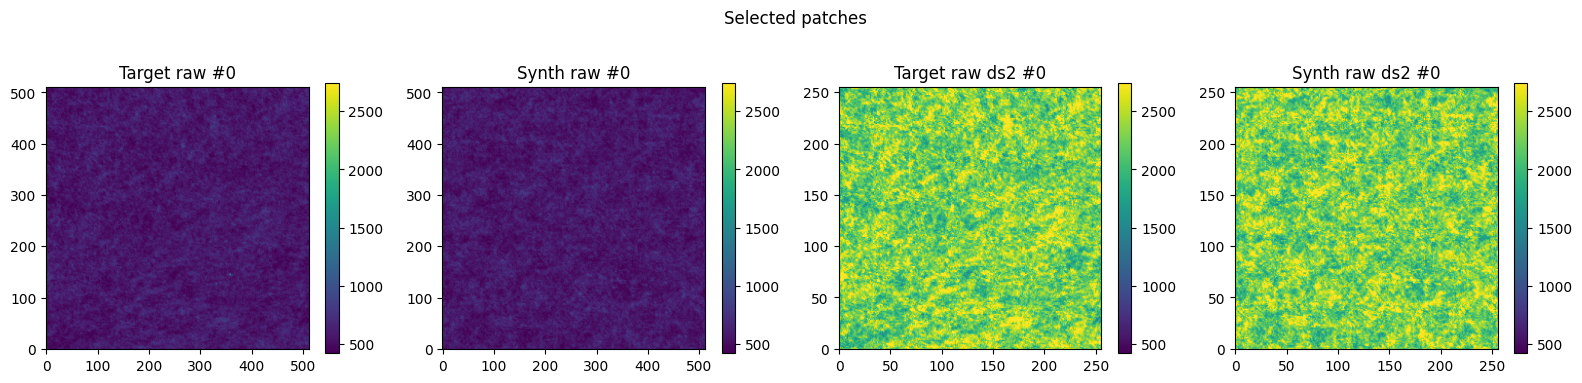

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x600 with 1 Axes>

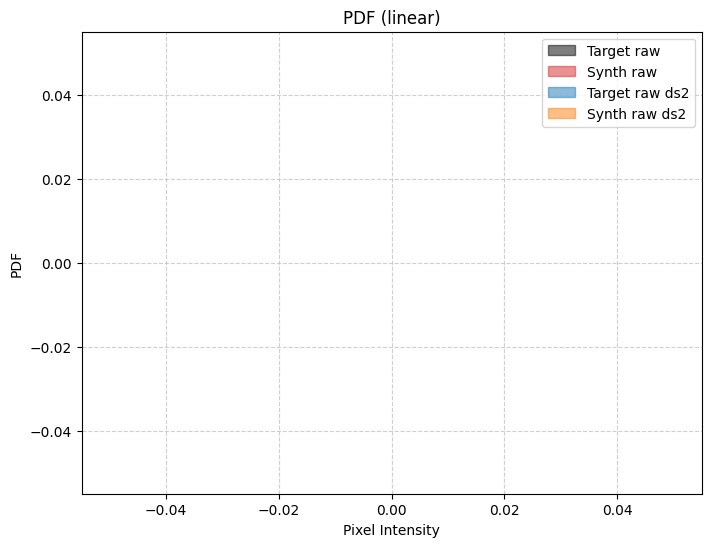

[DEBUG PS] Target raw min= 1143962195.803939 max= 360562233715.8104 any>0? True any nan? False shape= (10, 124)
[DEBUG PS] Synth raw min= 981502482.7581357 max= 365990057381.07947 any>0? True any nan? False shape= (10, 124)
[DEBUG PS] Target raw ds2 min= 929221591.9528966 max= 360228361105.71857 any>0? True any nan? False shape= (10, 124)
[DEBUG PS] Synth raw ds2 min= 840805466.005674 max= 365451075908.96936 any>0? True any nan? False shape= (10, 124)


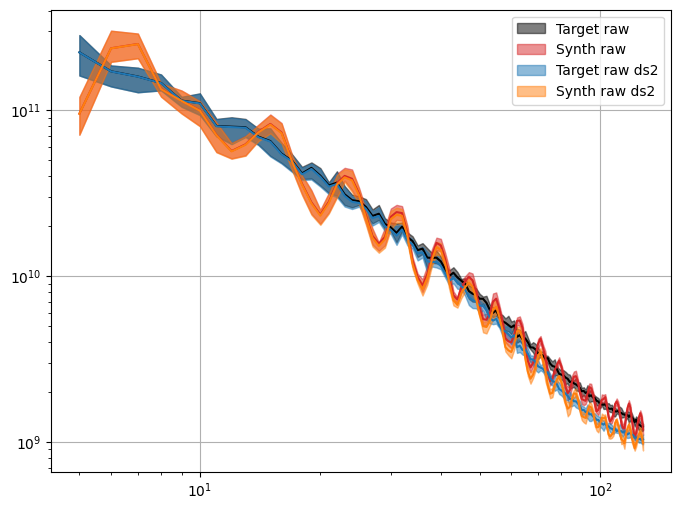

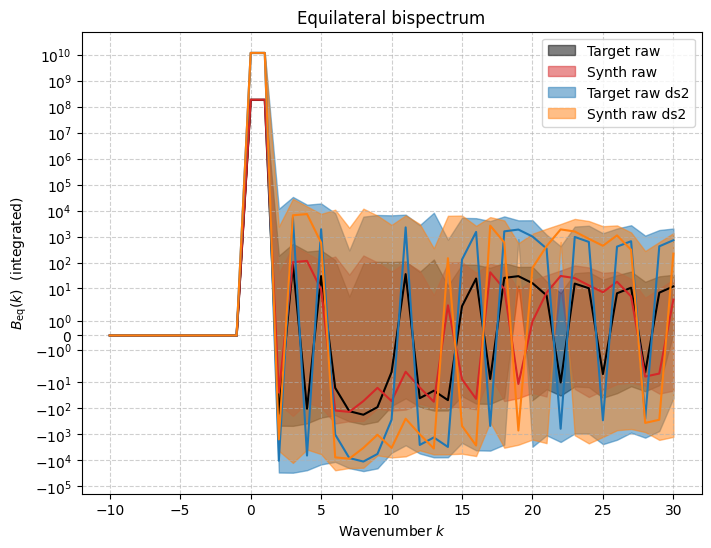

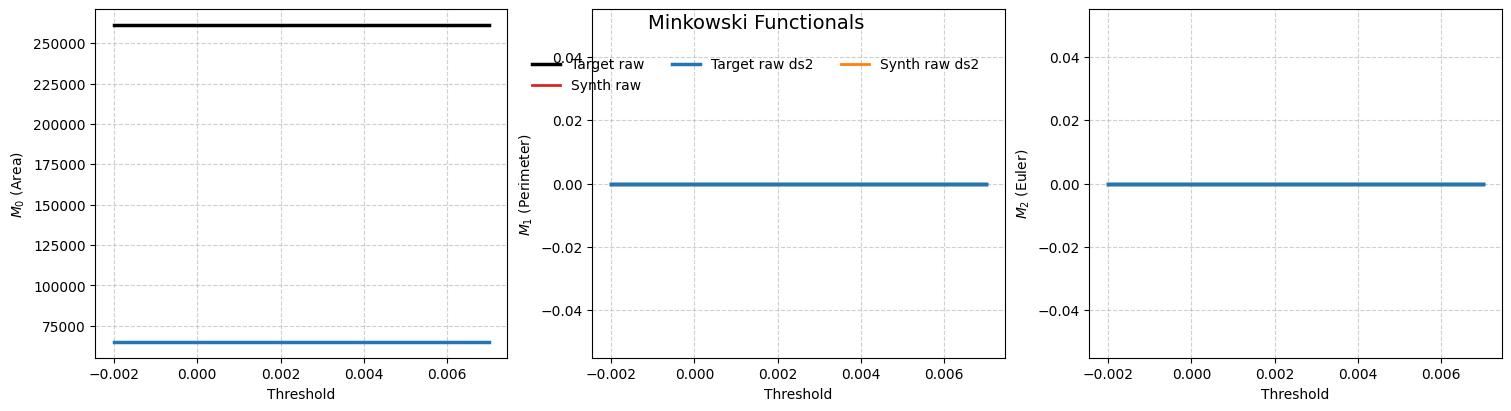

In [14]:
from clean_utils import flexible_analysis

fa_4way = flexible_analysis(
    folders=[OUT_PATCHES_RAW, OUT_SYNTH_RAW, OUT_PATCHES_RAW_DS, OUT_SYNTH_RAW_DS],
    labels=["Target raw", "Synth raw", "Target raw ds2", "Synth raw ds2"],
    colors=["black", "tab:red", "tab:blue", "tab:orange"],

    ps_kmin=5,
    ps_kmax=128,   

    ps_plot_individual_n=0,
    ps_individual_mode="top_impact",
    ps_individual_seed=0,

    imshow_indices=[0, 0, 0, 0],
    pdf_bins=80,
    pdf_range=(-1e-5, 6.5e-4),

    mf_min_threshold=-2e-3,
    mf_max_threshold=7e-3,

    gaussian=False,
    show=True,
    bispectrum=True,
    bisp_kmin=-10,
    bisp_kmax=30,
    bisp_width=2.0,
    bisp_yscale="symlog",
)


Again the patches with 512 pixels

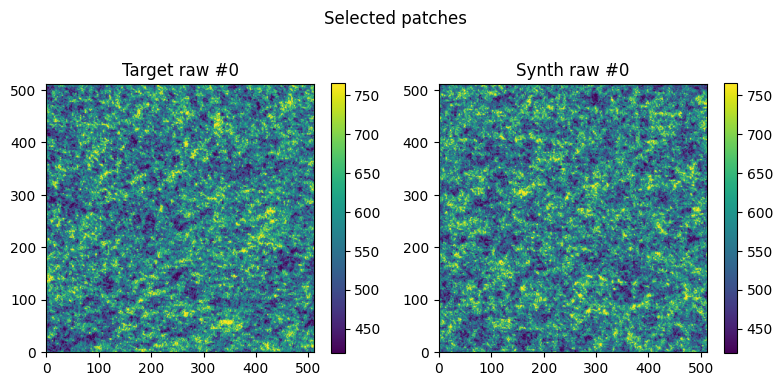

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x600 with 1 Axes>

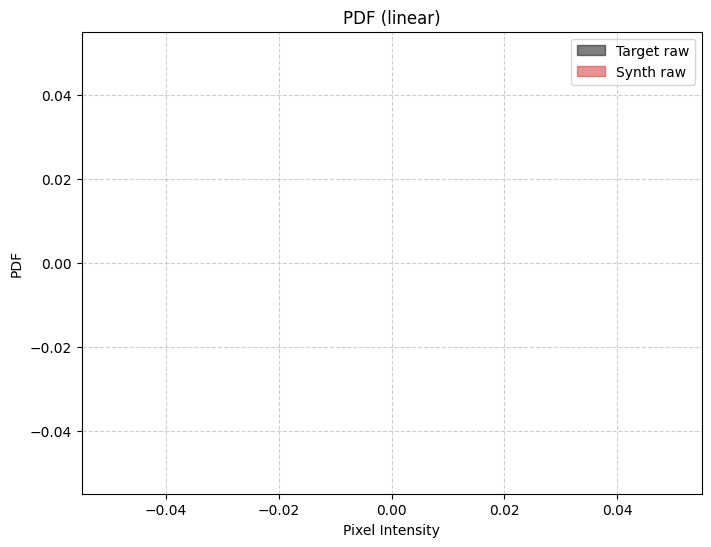

[DEBUG PS] Target raw min= 39393902.501604095 max= 360562233715.8104 any>0? True any nan? False shape= (10, 252)
[DEBUG PS] Synth raw min= 11713017.900669137 max= 365990057381.07947 any>0? True any nan? False shape= (10, 252)


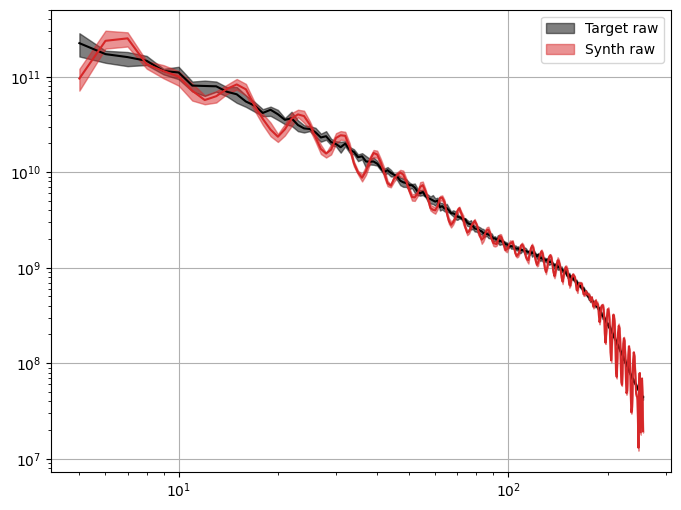

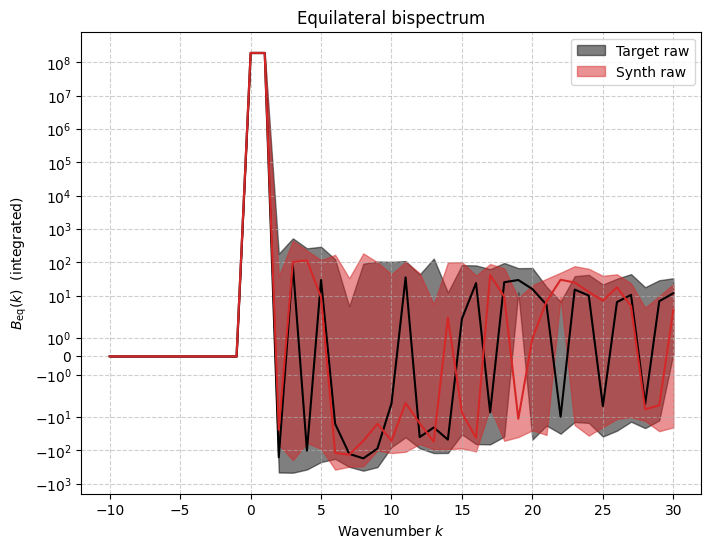

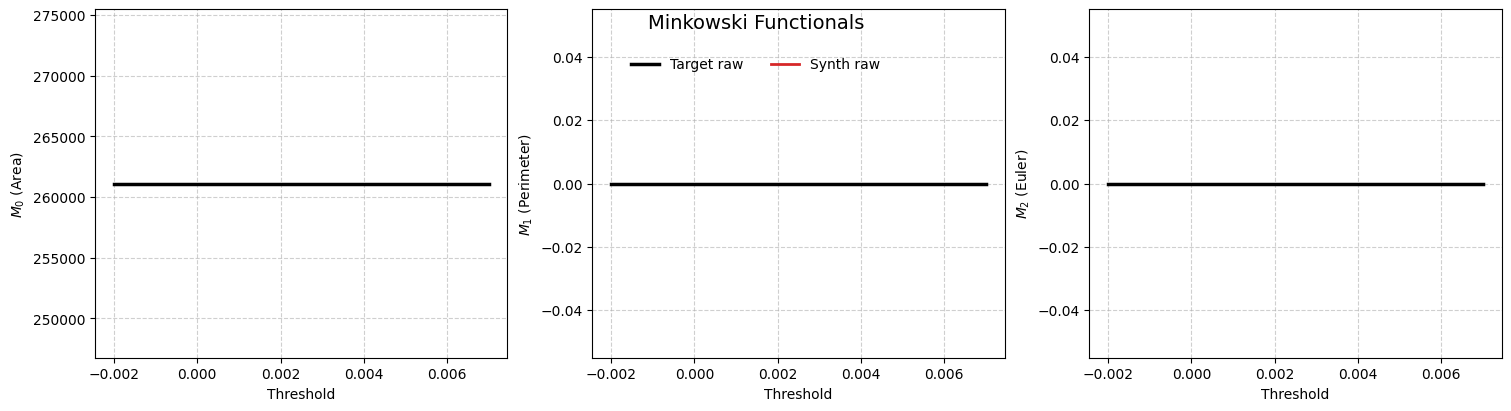

In [15]:
from clean_utils import flexible_analysis

fa_4way = flexible_analysis(
    folders=[OUT_PATCHES_RAW, OUT_SYNTH_RAW],
    labels=["Target raw", "Synth raw"],
    colors=["black", "tab:red"],

    ps_kmin=5,
    ps_kmax=256,   

    ps_plot_individual_n=0,
    ps_individual_mode="top_impact",
    ps_individual_seed=0,

    imshow_indices=[0, 0],
    pdf_bins=80,
    pdf_range=(-1e-5, 6.5e-4),

    mf_min_threshold=-2e-3,
    mf_max_threshold=7e-3,

    gaussian=False,
    show=True,
    bispectrum=True,
    bisp_kmin=-10,
    bisp_kmax=30,
    bisp_width=2.0,
    bisp_yscale="symlog",
)

Downsampled stats

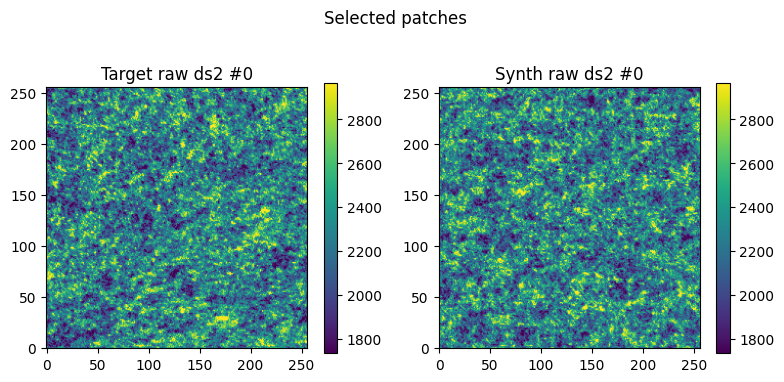

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x600 with 1 Axes>

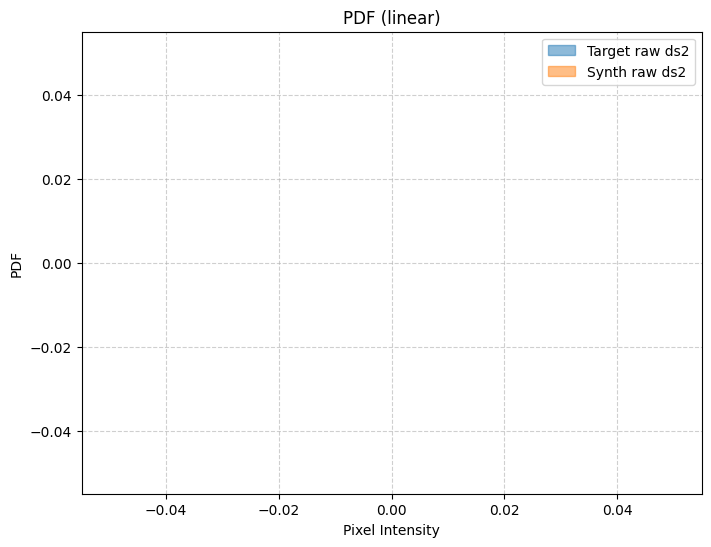

[DEBUG PS] Target raw ds2 min= 929221591.9528966 max= 360228361105.71857 any>0? True any nan? False shape= (10, 124)
[DEBUG PS] Synth raw ds2 min= 840805466.005674 max= 365451075908.96936 any>0? True any nan? False shape= (10, 124)


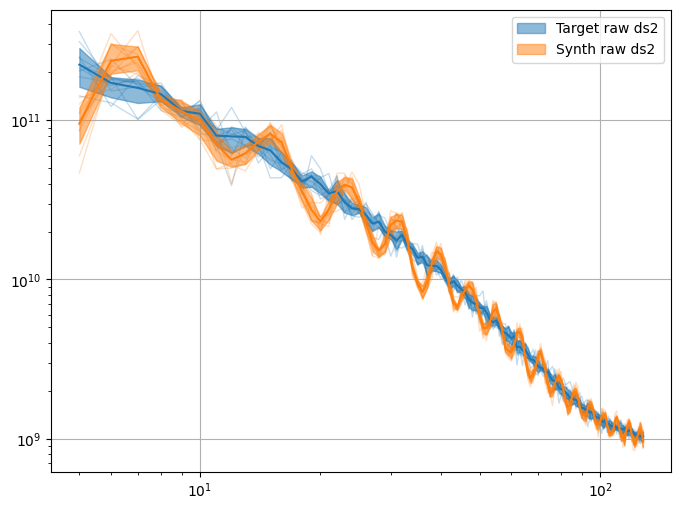

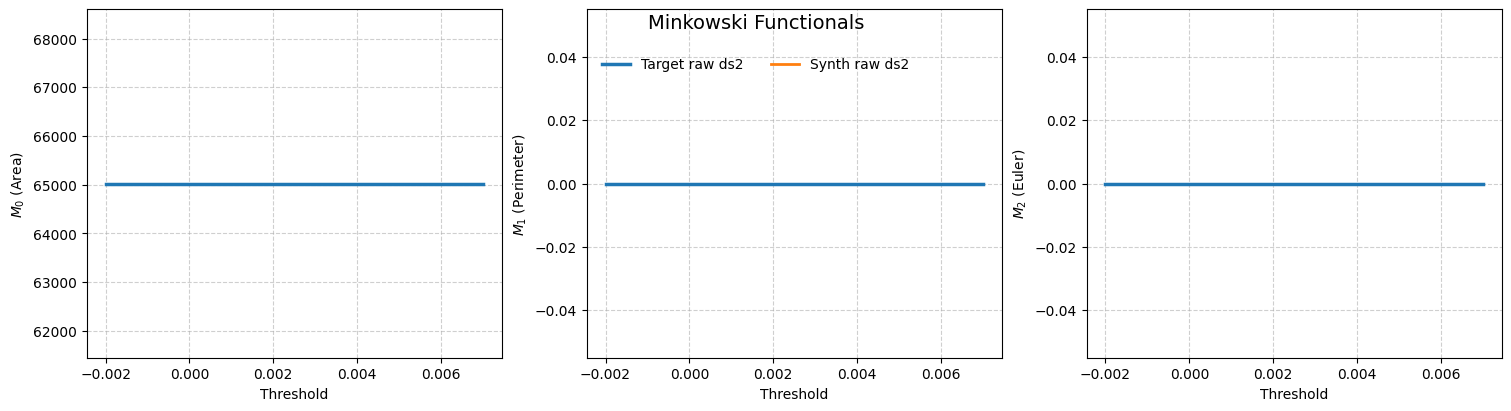

In [16]:
from clean_utils import flexible_analysis

fa_4way = flexible_analysis(
    folders=[OUT_PATCHES_RAW_DS, OUT_SYNTH_RAW_DS],
    labels= ["Target raw ds2", "Synth raw ds2"],
    colors=[ "tab:blue", "tab:orange"],

    ps_kmin=5,
    ps_kmax=150,   

    ps_plot_individual_n=10,
    ps_individual_mode="top_impact",
    ps_individual_seed=0,

    imshow_indices=[0, 0],
    pdf_bins=80,
    pdf_range=(-1e-5, 6.5e-4),

    mf_min_threshold=-2e-3,
    mf_max_threshold=7e-3,

    gaussian=False,
    show=True,
)


In [17]:
import glob, numpy as np, os

def inspect_patch_sizes(folder, name):
    files = sorted(glob.glob(os.path.join(folder, "*.npy")))
    if len(files) == 0:
        print(f"{name}: EMPTY")
        return
    shapes = [np.load(f).shape for f in files[:5]]
    print(f"{name}: example shapes = {shapes}")
    print(f"{name}: unique shapes = {sorted(set(shapes))}")

inspect_patch_sizes(OUT_PATCHES_RAW,     "Target raw")
inspect_patch_sizes(OUT_SYNTH_RAW,       "Synth raw")
inspect_patch_sizes(OUT_PATCHES_RAW_DS,  "Target raw ds2")
inspect_patch_sizes(OUT_SYNTH_RAW_DS,    "Synth raw ds2")

Target raw: example shapes = [(512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]
Target raw: unique shapes = [(512, 512)]
Synth raw: example shapes = [(512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]
Synth raw: unique shapes = [(512, 512)]
Target raw ds2: example shapes = [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]
Target raw ds2: unique shapes = [(256, 256)]
Synth raw ds2: example shapes = [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]
Synth raw ds2: unique shapes = [(256, 256)]


# Outliers detection

In [18]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

def _safe_log(x, eps=1e-30):
    return np.log10(np.maximum(x, eps))

def find_ps_outliers(
    folder,
    kmin=5,
    kmax=226,
    top=5,
    metric="l2_log",  # "l2_log" | "linf_log"
    normalize_amp=True,
    verbose=True,
):
    files = sorted(glob.glob(os.path.join(folder, "*.npy")))
    if len(files) == 0:
        raise ValueError(f"No .npy files in {folder}")

    ps_list = []
    kept_files = []
    kvals_ref = None

    for f in files:
        img = np.load(f)
        img = np.asarray(img)
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        if img.ndim != 2:
            continue
        if img.shape[0] != img.shape[1]:
            continue

        k, P = power_spectrum(img)  # <-- ta fonction
        if kvals_ref is None:
            kvals_ref = k
        else:
            # au cas où (normalement identique si même taille)
            if len(k) != len(kvals_ref) or np.any(k != kvals_ref):
                # on skip pour éviter les ennuis (ou on interpole si besoin)
                continue

        ps_list.append(P)
        kept_files.append(f)

    ps = np.array(ps_list)  # (N, Nk)
    k = np.array(kvals_ref)

    # masque k
    mask = np.ones_like(k, dtype=bool)
    if kmin is not None: mask &= (k >= kmin)
    if kmax is not None: mask &= (k <= kmax)
    k_m = k[mask]
    ps_m = ps[:, mask]

    # nettoyage (évite nan/inf)
    finite = np.isfinite(ps_m)
    ps_m = np.where(finite, ps_m, np.nan)

    # option: normaliser l’amplitude globale (pour détecter surtout une *forme* bizarre)
    if normalize_amp:
        # normalisation par la moyenne en log (équiv à diviser par une amplitude globale)
        lp = _safe_log(ps_m)
        lp = lp - np.nanmean(lp, axis=1, keepdims=True)
    else:
        lp = _safe_log(ps_m)

    # spectre "central" robuste = médiane
    center = np.nanmedian(lp, axis=0)

    # score d'écart
    diff = lp - center[None, :]
    if metric == "l2_log":
        score = np.sqrt(np.nanmean(diff**2, axis=1))
    elif metric == "linf_log":
        score = np.nanmax(np.abs(diff), axis=1)
    else:
        raise ValueError("metric must be 'l2_log' or 'linf_log'")

    order = np.argsort(score)[::-1]
    out = [(kept_files[i], float(score[i])) for i in order[:top]]

    if verbose:
        print(f"Kept {len(kept_files)}/{len(files)} square 2D patches.")
        print("Top outliers:")
        for f, s in out:
            print(f"  score={s:.4g}  file={os.path.basename(f)}")

    return {
        "k": k_m,
        "center_log": center,
        "scores": score,
        "files": kept_files,
        "ranking": order,
        "top": out,
    }


In [19]:
from clean_utils import *

res = find_ps_outliers(
    OUT_SYNTH_RAW,
    kmin=5, kmax=226,
    top=10,
    metric="l2_log",
    normalize_amp=True,
)

# Le pire (le plus éloigné)
worst_file, worst_score = res["top"][0]
print("WORST =", worst_file, worst_score)

Kept 10/10 square 2D patches.
Top outliers:
  score=0.03679  file=synth_raw_004.npy
  score=0.03654  file=synth_raw_000.npy
  score=0.0347  file=synth_raw_003.npy
  score=0.03427  file=synth_raw_007.npy
  score=0.03395  file=synth_raw_008.npy
  score=0.03357  file=synth_raw_002.npy
  score=0.03279  file=synth_raw_009.npy
  score=0.03005  file=synth_raw_001.npy
  score=0.02963  file=synth_raw_005.npy
  score=0.02873  file=synth_raw_006.npy
WORST = /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/synth_raw/synth_raw_004.npy 0.03679102986267301


In [20]:
import os, glob, shutil

outlier = "synth_raw_006.npy"

SRC = OUT_SYNTH_RAW
DST = OUT_SYNTH_RAW.rstrip("/")+ "_no006"   # ex: .../synth_raw_no006
os.makedirs(DST, exist_ok=True)

files = sorted(glob.glob(os.path.join(SRC, "*.npy")))
kept = [f for f in files if os.path.basename(f) != outlier]

print("SRC:", SRC)
print("DST:", DST)
print("N src :", len(files))
print("N kept:", len(kept))

# Option A (recommandé sur cluster): symlinks (rapide, pas de duplication)
for f in kept:
    link = os.path.join(DST, os.path.basename(f))
    if os.path.islink(link) or os.path.exists(link):
        os.remove(link)
    os.symlink(f, link)

# Option B (si symlink interdit): copier
# for f in kept:
#     shutil.copy2(f, os.path.join(DST, os.path.basename(f)))


SRC: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/synth_raw
DST: /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/synth_raw_no006
N src : 10
N kept: 9


In [21]:
print("N dst :", len(sorted(glob.glob(os.path.join(DST, '*.npy')))))

N dst : 9


N target raw files: 10
N synth raw files (filtered): 9


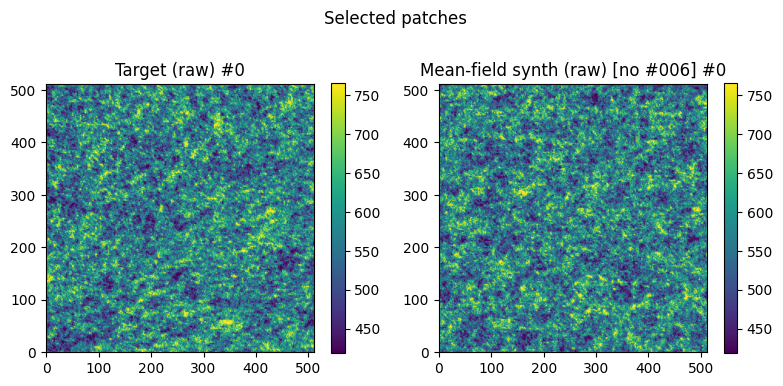

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x600 with 1 Axes>

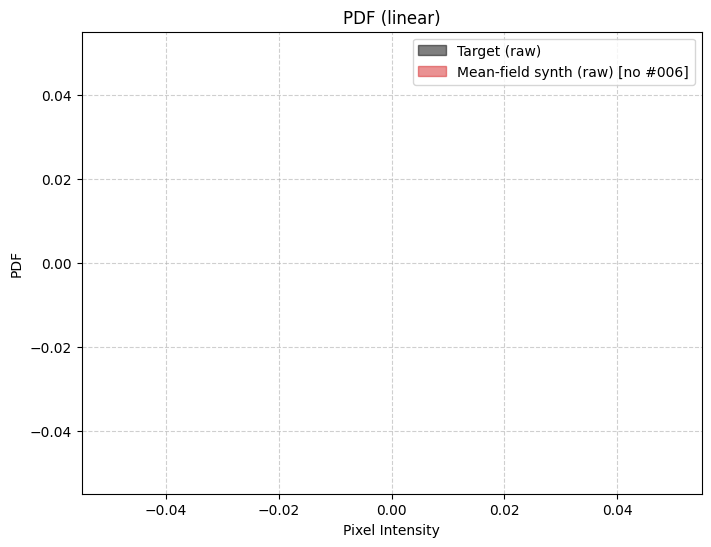

[DEBUG PS] Target (raw) min= 93339886.0378933 max= 360562233715.8104 any>0? True any nan? False shape= (10, 222)
[DEBUG PS] Mean-field synth (raw) [no #006] min= 56617794.48128145 max= 365990057381.07947 any>0? True any nan? False shape= (9, 222)


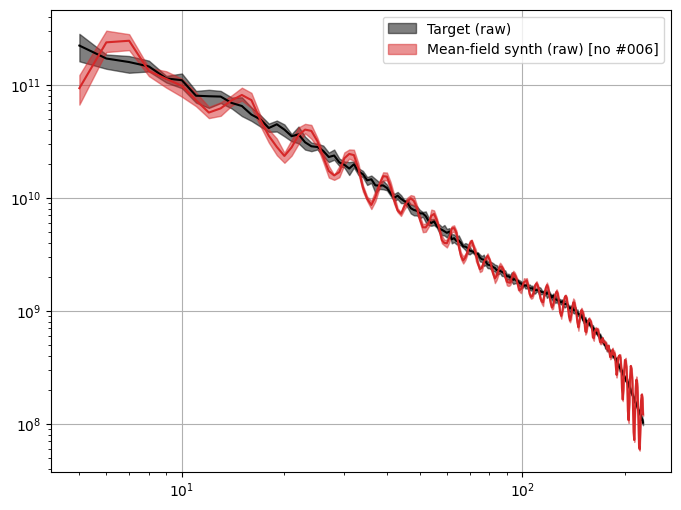

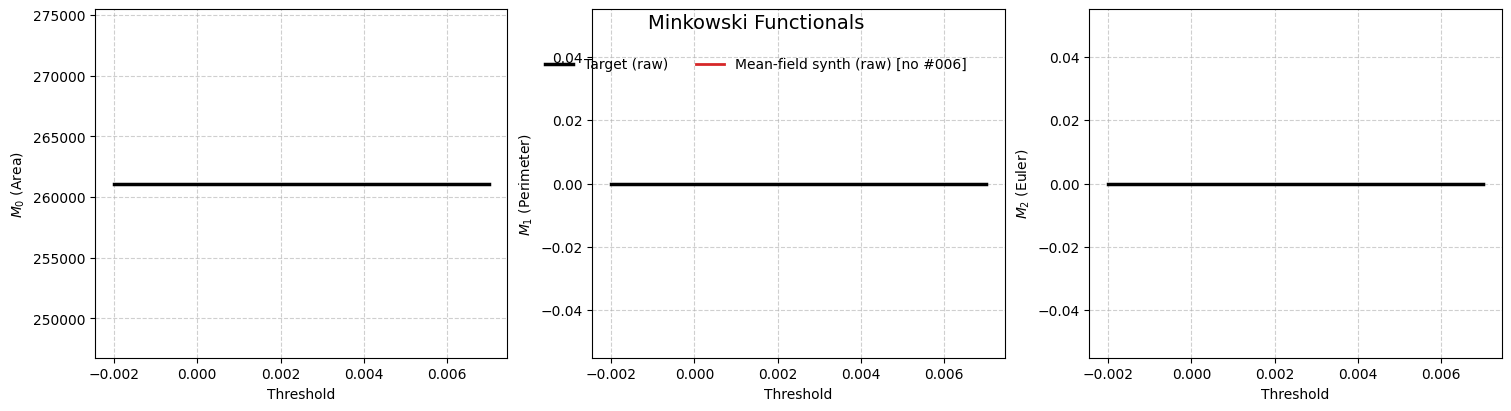

In [22]:
from clean_utils import flexible_analysis
import glob, os

tar_files = sorted(glob.glob(os.path.join(OUT_PATCHES_RAW, "*.npy")))
synth_files = sorted(glob.glob(os.path.join(DST, "*.npy")))
print("N target raw files:", len(tar_files))
print("N synth raw files (filtered):", len(synth_files))

fa_raw_2 = flexible_analysis(
    folders=[OUT_PATCHES_RAW, DST],
    labels=["Target (raw)", "Mean-field synth (raw) [no #006]"],
    colors=["black", "tab:red"],
    ps_kmin=5, ps_kmax=226,
    ps_plot_individual_n=0,
    ps_individual_mode="top_impact",
    ps_individual_seed=0,
    imshow_indices=[0, 0],
    pdf_bins=80,
    pdf_range=(-1e-5, 6.5e-4),
    mf_min_threshold=-2e-3,
    mf_max_threshold=7e-3,
    gaussian=False,
    show=True,
)


In [23]:
import os, glob

print("OUT_PATCHES_RAW =", OUT_PATCHES_RAW)
print("exists?", os.path.isdir(OUT_PATCHES_RAW))
print("npy count:", len(glob.glob(os.path.join(OUT_PATCHES_RAW, "*.npy"))))

OUT_PATCHES_RAW = /rds/rds-clecat/generative_modelling/run3_logmeanfield_cibONLY_ps_2/patches_raw
exists? True
npy count: 10


In [24]:
import glob, os

tar_files = sorted(glob.glob(os.path.join(OUT_PATCHES_RAW, "*.npy")))
if len(tar_files) == 0:
    raise RuntimeError(
        f"OUT_PATCHES_RAW is empty: {OUT_PATCHES_RAW}\n"
        "Run Cell B (denormalize -> patches_raw) before flexible_analysis."
    )


# Compare low frequencies

In [25]:
import os, glob
import numpy as np
from clean_utils import flexible_analysis

TARGET_DIR = "/rds/rds-clecat/generative_modelling/run3_logmeanfield_tszONLY_ps_2/patches_raw"
SYNTH_DIR  = "/rds/rds-clecat/generative_modelling/run3_logmeanfield_tszONLY_ps_2/synth_raw_no006"

# === paramètres filtrage ===
K_CUT = 10         
MODE  = "lowpass"  

# === sorties (dossiers filtrés) ===
TARGET_DIR_LF = TARGET_DIR.rstrip("/") + f"_lf_k{K_CUT}"
SYNTH_DIR_LF  = SYNTH_DIR.rstrip("/")  + f"_lf_k{K_CUT}"
os.makedirs(TARGET_DIR_LF, exist_ok=True)
os.makedirs(SYNTH_DIR_LF,  exist_ok=True)


n_tar = filter_folder(TARGET_DIR, TARGET_DIR_LF, k_cut=K_CUT, mode=MODE, overwrite=False)
n_syn = filter_folder(SYNTH_DIR,  SYNTH_DIR_LF,  k_cut=K_CUT, mode=MODE, overwrite=False)

print("Target in :", TARGET_DIR, "-> out:", TARGET_DIR_LF, "N:", n_tar)
print("Synth in  :", SYNTH_DIR,  "-> out:", SYNTH_DIR_LF,  "N:", n_syn)

Target in : /rds/rds-clecat/generative_modelling/run3_logmeanfield_tszONLY_ps_2/patches_raw -> out: /rds/rds-clecat/generative_modelling/run3_logmeanfield_tszONLY_ps_2/patches_raw_lf_k10 N: 10
Synth in  : /rds/rds-clecat/generative_modelling/run3_logmeanfield_tszONLY_ps_2/synth_raw_no006 -> out: /rds/rds-clecat/generative_modelling/run3_logmeanfield_tszONLY_ps_2/synth_raw_no006_lf_k10 N: 9


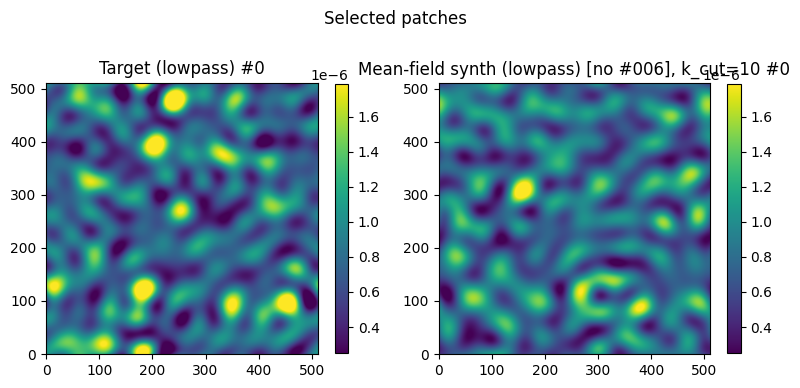

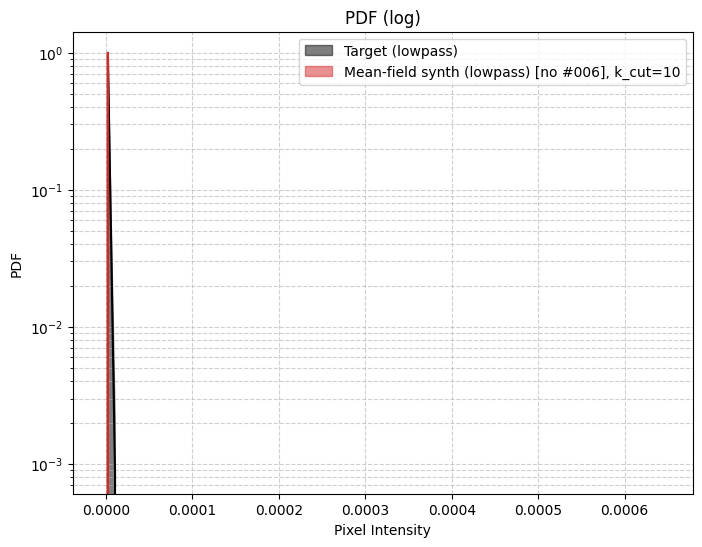

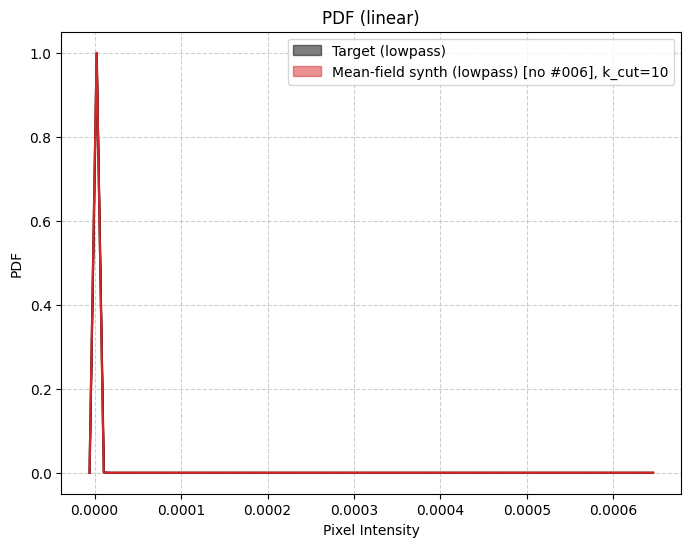

[DEBUG PS] Target (lowpass) min= 9.023310346665487e-23 max= 0.00014639910056385812 any>0? True any nan? False shape= (10, 222)
[DEBUG PS] Mean-field synth (lowpass) [no #006], k_cut=10 min= 7.681562137964511e-23 max= 6.883538821068211e-05 any>0? True any nan? False shape= (9, 222)


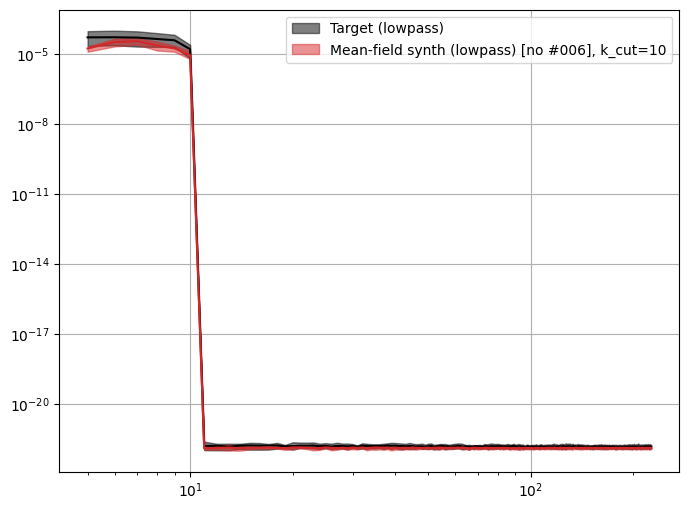

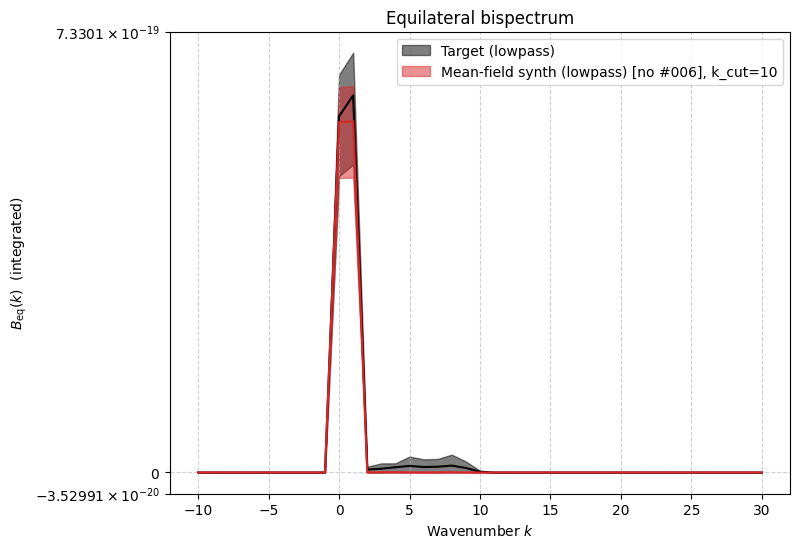

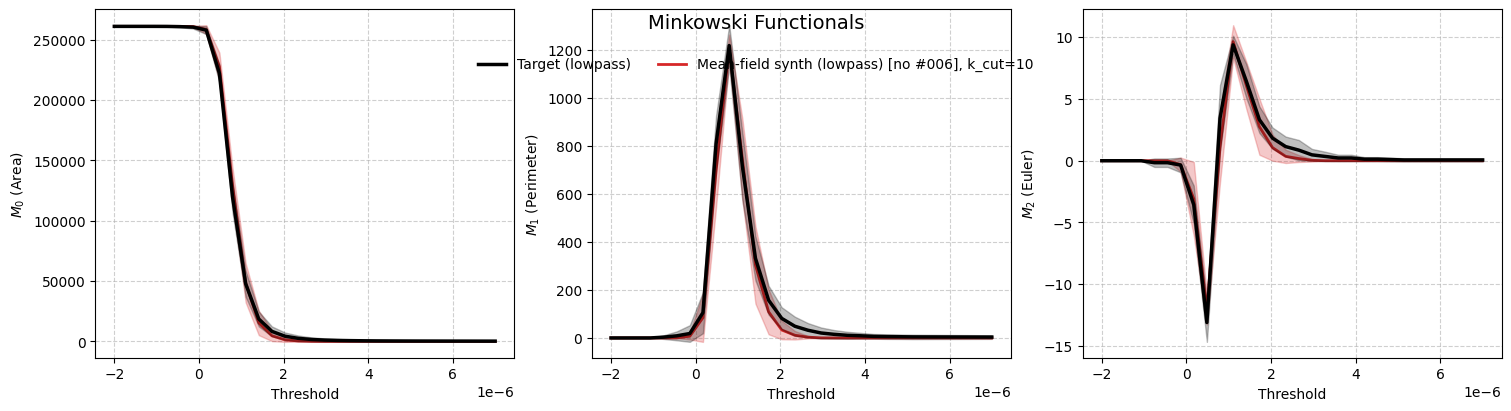

In [26]:
fa_lf = flexible_analysis(
    folders=[TARGET_DIR_LF, SYNTH_DIR_LF],
    labels=["Target (lowpass)", f"Mean-field synth (lowpass) [no #006], k_cut={K_CUT}"],
    colors=["black", "tab:red"],
    ps_kmin=5, ps_kmax=226,
    ps_plot_individual_n=0,
    ps_individual_mode="top_impact",
    ps_individual_seed=0,
    imshow_indices=[0, 0],
    pdf_bins=80,
    pdf_range=(-1e-5, 6.5e-4),
    mf_min_threshold=-2e-6,
    mf_max_threshold=7e-6,
    gaussian=False,
    show=True,
    bispectrum=True,
    bisp_kmin=-10,
    bisp_kmax=30,
    bisp_width=2.0,
    bisp_yscale="symlog",
)